# Week 9 Challenge

## Task 1: Data Preprocessing and Exploratory Data Analysis

Author: Lalise Fufi

Date: July 2026

In [1]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf

from sklearn.preprocessing import MinMaxScaler

from statsmodels.tsa.stattools import adfuller

plt.style.use("ggplot")

%matplotlib inline

2. Download Data

In [2]:
# ==========================================================
# Download Historical Data
# ==========================================================

start_date = "2015-01-01"
end_date = "2026-06-30"

tsla = yf.download("TSLA", start=start_date, end=end_date)

bnd = yf.download("BND", start=start_date, end=end_date)

spy = yf.download("SPY", start=start_date, end=end_date)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


3. View Data

In [3]:
tsla.head()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2015-01-02,14.620667,14.883333,14.217333,14.858000,71466000
2015-01-05,14.006000,14.433333,13.810667,14.303333,80527500
2015-01-06,14.085333,14.280000,13.614000,14.004000,93928500
2015-01-07,14.063333,14.318667,13.985333,14.223333,44526000
2015-01-08,14.041333,14.253333,14.000667,14.187333,51637500


In [4]:
bnd.head()

Price,Close,High,Low,Open,Volume
Ticker,BND,BND,BND,BND,BND
Date,,,,,
2015-01-02,59.405437,59.434188,59.240120,59.247310,2218800
2015-01-05,59.577896,59.599458,59.441330,59.470081,5820100
2015-01-06,59.750427,59.930117,59.678552,59.678552,3887600
2015-01-07,59.786358,59.858233,59.692921,59.757607,2433400
2015-01-08,59.692883,59.736006,59.635381,59.736006,1873400


In [5]:
spy.head()

Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2015-01-02,169.687881,170.885611,168.655365,170.472604,121465900
2015-01-05,166.623337,168.812266,166.317716,168.647066,169632600
2015-01-06,165.053864,167.449295,164.260886,166.928903,209151400
2015-01-07,167.110733,167.449401,165.929540,166.375582,125346700
2015-01-08,170.076065,170.290837,168.498390,168.514901,147217800


4. Save Raw Data

In [6]:
tsla.to_csv("../data/raw/TSLA.csv")
bnd.to_csv("../data/raw/BND.csv")
spy.to_csv("../data/raw/SPY.csv")

5. Data Information

In [7]:
tsla.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2888 entries, 2015-01-02 to 2026-06-29
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, TSLA)   2888 non-null   float64
 1   (High, TSLA)    2888 non-null   float64
 2   (Low, TSLA)     2888 non-null   float64
 3   (Open, TSLA)    2888 non-null   float64
 4   (Volume, TSLA)  2888 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 135.4 KB


In [8]:
bnd.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2888 entries, 2015-01-02 to 2026-06-29
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, BND)   2888 non-null   float64
 1   (High, BND)    2888 non-null   float64
 2   (Low, BND)     2888 non-null   float64
 3   (Open, BND)    2888 non-null   float64
 4   (Volume, BND)  2888 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 135.4 KB


In [9]:
spy.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2888 entries, 2015-01-02 to 2026-06-29
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, SPY)   2888 non-null   float64
 1   (High, SPY)    2888 non-null   float64
 2   (Low, SPY)     2888 non-null   float64
 3   (Open, SPY)    2888 non-null   float64
 4   (Volume, SPY)  2888 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 135.4 KB


6. Summary Statistics

In [10]:
tsla.describe()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
count,2888.000000,2888.000000,2888.000000,2888.000000,2.888000e+03
mean,148.773923,151.990563,145.416731,148.797341,1.087922e+08
std,138.895957,141.852818,135.867193,138.977191,7.082549e+07
min,9.578000,10.331333,9.403333,9.488000,1.062000e+07
25%,18.393499,18.665168,18.023666,18.390833,6.548325e+07
50%,133.437668,136.053329,125.831669,131.496330,9.033615e+07
75%,251.925831,257.485008,245.832500,251.680004,1.261204e+08
max,489.880005,498.829987,485.329987,489.880005,9.140820e+08


In [11]:
bnd.describe()

Price,Close,High,Low,Open,Volume
Ticker,BND,BND,BND,BND,BND
count,2888.000000,2888.000000,2888.000000,2888.000000,2.888000e+03
mean,66.503053,66.600149,66.404061,66.505297,4.653786e+06
std,4.713607,4.719859,4.705621,4.713244,3.017704e+06
min,58.729187,58.801823,58.692884,58.758233,0.000000e+00
25%,62.478080,62.536705,62.405132,62.472859,2.233700e+06
50%,65.728409,65.852774,65.596763,65.712503,4.280650e+06
75%,70.689131,70.843027,70.549760,70.688894,6.246475e+06
max,74.832901,74.924907,74.799448,74.891460,3.396300e+07


In [12]:
spy.describe()

Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
count,2888.000000,2888.000000,2888.000000,2888.000000,2.888000e+03
mean,351.505531,353.335694,349.374634,351.441777,8.551049e+07
std,155.443934,156.153560,154.576727,155.414685,4.338553e+07
min,154.161636,155.207033,152.073406,153.723242,2.027000e+07
25%,223.546810,224.825591,222.172493,223.474590,5.836455e+07
50%,312.817932,315.491376,310.494715,314.142292,7.541950e+07
75%,432.806839,434.994781,430.305320,432.604458,9.882245e+07
max,757.618225,758.446109,754.805464,756.201867,5.072443e+08


7. Missing Values

In [13]:
tsla.isnull().sum()

Price   Ticker
Close   TSLA      0
High    TSLA      0
Low     TSLA      0
Open    TSLA      0
Volume  TSLA      0
dtype: int64

In [14]:
bnd.isnull().sum()

Price   Ticker
Close   BND       0
High    BND       0
Low     BND       0
Open    BND       0
Volume  BND       0
dtype: int64

In [15]:
spy.isnull().sum()

Price   Ticker
Close   SPY       0
High    SPY       0
Low     SPY       0
Open    SPY       0
Volume  SPY       0
dtype: int64

8. Handle Missing Values

In [17]:
tsla = tsla.ffill().bfill()

bnd = bnd.ffill().bfill()

spy = spy.ffill().bfill()

9. Data Types

In [18]:
tsla.dtypes

Price   Ticker
Close   TSLA      float64
High    TSLA      float64
Low     TSLA      float64
Open    TSLA      float64
Volume  TSLA        int64
dtype: object

In [19]:
bnd.dtypes

Price   Ticker
Close   BND       float64
High    BND       float64
Low     BND       float64
Open    BND       float64
Volume  BND         int64
dtype: object

In [20]:
spy.dtypes

Price   Ticker
Close   SPY       float64
High    SPY       float64
Low     SPY       float64
Open    SPY       float64
Volume  SPY         int64
dtype: object

10. Normalize Closing Prices

In [21]:
scaler = MinMaxScaler()

tsla["Scaled Close"] = scaler.fit_transform(tsla[["Close"]])

bnd["Scaled Close"] = scaler.fit_transform(bnd[["Close"]])

spy["Scaled Close"] = scaler.fit_transform(spy[["Close"]])

11. Plot Closing Prices

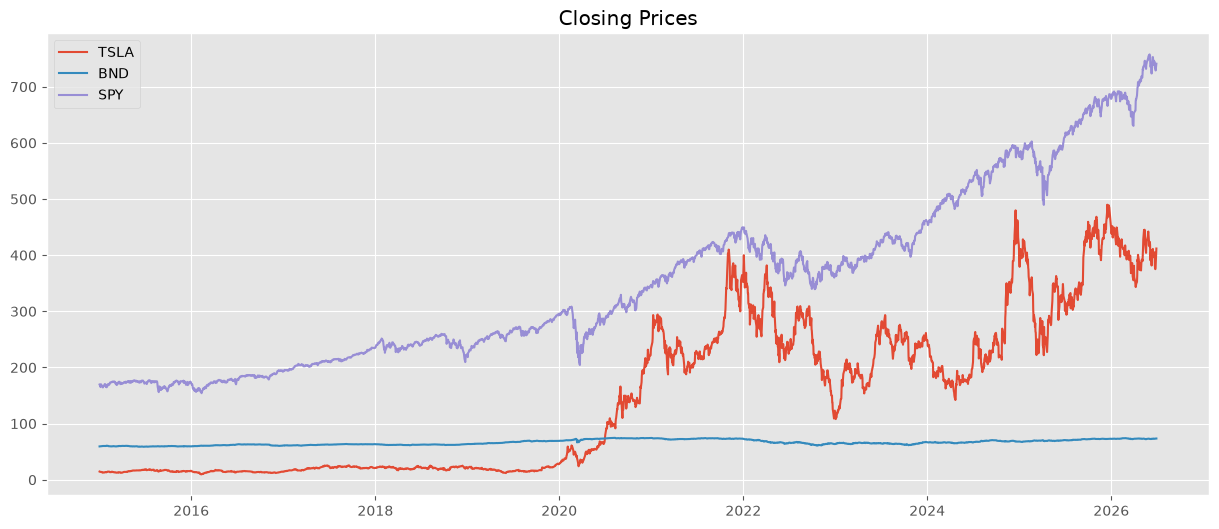

In [22]:
plt.figure(figsize=(15,6))

plt.plot(tsla.index, tsla["Close"], label="TSLA")
plt.plot(bnd.index, bnd["Close"], label="BND")
plt.plot(spy.index, spy["Close"], label="SPY")

plt.title("Closing Prices")

plt.legend()

plt.show()

## Interpretation of Closing Price Trends

### Key Observations

The chart shows the historical closing prices of **Tesla (TSLA)**, **Vanguard Total Bond Market ETF (BND)**, and the **SPDR S&P 500 ETF (SPY)** from **January 2015 to June 2026**.

- **Tesla (TSLA)** experienced the highest price volatility among the three assets. Its stock price remained relatively low until 2020, after which it increased rapidly with several sharp rises and declines. This behavior reflects Tesla's high-risk, high-return nature and indicates that investors experienced significant price fluctuations over the study period.

- **BND** maintained a relatively stable price throughout the entire period. Compared to TSLA and SPY, BND showed only small price movements, making it the least volatile asset. This stability is expected because BND is a bond ETF designed to provide steady income with lower investment risk.

- **SPY** displayed a consistent long-term upward trend despite temporary declines during periods of market uncertainty. Although its price fluctuated over time, the movements were much smoother than Tesla's, demonstrating moderate risk and long-term market growth.

### Business Insight

From a portfolio management perspective:

- **TSLA** offers the greatest potential for capital appreciation but also carries substantial investment risk due to its high volatility.
- **BND** acts as a defensive asset that helps reduce overall portfolio risk.
- **SPY** provides diversified exposure to the U.S. stock market and delivers a balance between growth and stability.

These observations suggest that combining all three assets can improve portfolio diversification by balancing expected returns with investment risk.

12. Daily Returns